In [39]:
%load_ext autoreload
%autoreload 2

import os
import gc

import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from dataset import FacesDataset
from augmentations import get_train_transform, get_test_transform
from train_gan_ebm import train_gan_ebm_full, build_gan_models, train_gan_with_epoch_callback
from gan_generate import (
    generate_samples,
    show_images,
    save_samples,
    compute_fid,
    compute_is,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 32

# Load data
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

# Add image paths
for df in [train_df, test_df]:
    df["image_path"] = df["id"].apply(
        lambda x: f"data/processed_64/face-{int(x)}.png"
    )

# Create datasets and dataloaders
train_loader = DataLoader(
    FacesDataset(train_df, transform=get_train_transform(64)), 
    batch_size=batch_size, shuffle=True
)
test_loader = DataLoader(
    FacesDataset(test_df, transform=get_test_transform(64)), 
    batch_size=batch_size, shuffle=False
)

# Configuration
base_config = {
    "latent_dim": 128,
    "g_channels": [512, 256, 128, 64],
    "d_channels": [64, 128, 256, 512],
    "use_batchnorm": True,

    # Activations
    "g_activation": "relu",      
    "e_activation": "leakyrelu",

    # Dropout
    "g_dropout": 0.0,            
    "e_dropout": 0.0,

    # Optim / training balance
    "lr": 2e-4,
    "lr_G": 2e-4,                
    "lr_E": 1e-4,                
    "k_steps": 5,                
    "g_steps": 1,                
    "real_ratio": 0.5,           
    "gp_lambda": 10.0,
}

In [ ]:
# Helpers for evaluation and post-evaluation memory cleanup

def free_model_memory(*objects):
    """Move models to CPU and clear Python/CUDA memory references."""
    for obj in objects:
        if obj is None:
            continue
        if isinstance(obj, torch.nn.Module):
            obj.to("cpu")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def evaluate_and_save(G, device, latent_dim, save_path, test_loader=None):
    """Evaluate GAN and save generated samples."""
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    fid_score = compute_fid(G, test_loader or train_loader, device, latent_dim=latent_dim)
    is_score = compute_is(G, device, latent_dim=latent_dim)
    save_samples(G, device, save_path, latent_dim=latent_dim)

    return fid_score, is_score

In [25]:
# Ablation Table Visualization Function
def plot_ablation_cards(df, title_fontsize=16, metrics_fontsize=11, max_height="80vh"):
    """Render a column-wise ablation table inside a scrollable container."""
    import base64
    import html
    import os

    from IPython.display import HTML, display

    if df is None or df.empty:
        display(HTML('<div style="padding: 12px; font-family: sans-serif;">No ablation results to display.</div>'))
        return

    frame = df.reset_index(drop=True).copy()
    columns = list(frame.columns)
    experiment_col = "experiment" if "experiment" in columns else columns[0]
    image_col = "image_path" if "image_path" in columns else None

    # Make the table narrower when there are many experiments, but never too small to read.
    n_experiments = len(frame)
    column_width = max(180, min(320, int(1800 / max(1, n_experiments))))
    image_max_height = max(140, min(260, int(1400 / max(1, n_experiments))))

    metric_rows = [
        ("Loss", lambda row: f"{row['loss']:.4f}"),
        ("Train FID", lambda row: f"{row['train_fid']:.4f}"),
        ("Eval FID", lambda row: f"{row['eval_fid']:.4f}"),
        ("Train IS", lambda row: f"{row['train_is']:.4f}"),
        ("Eval IS", lambda row: f"{row['eval_is']:.4f}"),
        ("Changes", lambda row: str(row['changed_params'])),
    ]

    def render_image(path):
        if not path or not os.path.exists(path):
            return '<div style="color:#8a8f98; font-size: 12px;">Image not found</div>'
        with open(path, 'rb') as image_file:
            encoded = base64.b64encode(image_file.read()).decode('ascii')
        return (
            f'<img src="data:image/png;base64,{encoded}" '
            f'style="max-width: 100%; max-height: {image_max_height}px; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />'
        )

    table_style = f'''
        <style>
            .ablation-wrap {{
                max-width: 100%;
                max-height: {max_height};
                overflow: auto;
                border: 1px solid #5b534f;
                border-radius: 12px;
                background: #3c3836;
                box-shadow: 0 2px 10px rgba(0, 0, 0, 0.15);
            }}
            .ablation-table {{
                border-collapse: collapse;
                width: max-content;
                min-width: 100%;
                font-family: sans-serif;
                color: #f4e8d5;
            }}
            .ablation-table th, .ablation-table td {{
                border: 1px solid #5b534f;
                padding: 10px 12px;
                vertical-align: top;
                text-align: center;
                min-width: {column_width}px;
                background: #3c3836;
            }}
            .ablation-table th.row-header, .ablation-table td.row-header {{
                position: sticky;
                left: 0;
                z-index: 2;
                background: #4a433f;
                color: #f4e8d5;
                text-align: left;
                min-width: 160px;
                font-weight: 700;
            }}
            .ablation-table thead th {{
                position: sticky;
                top: 0;
                z-index: 3;
                background: #2f2b28;
                color: #f4e8d5;
                font-size: {title_fontsize}px;
            }}
            .ablation-table tbody tr:nth-child(even) td {{
                background: #433d3a;
            }}
            .metric-value {{
                font-size: {metrics_fontsize}px;
                line-height: 1.45;
                word-break: break-word;
                color: #f4e8d5;
            }}
            .experiment-name {{
                font-weight: 700;
                font-size: {metrics_fontsize + 1}px;
                margin-bottom: 8px;
                word-break: break-word;
                color: #f4e8d5;
            }}
        </style>
    '''

    header_cells = ''.join(
        f'<th>{html.escape(str(row[experiment_col]))}</th>' for _, row in frame.iterrows()
    )

    body_rows = []
    image_cells = []
    for _, row in frame.iterrows():
        image_html = render_image(str(row[image_col])) if image_col is not None else '<div style="color:#8a8f98;">No image path</div>'
        image_cells.append(f'<td>{image_html}</td>')

    body_rows.append('<tr><td class="row-header">Image</td>' + ''.join(image_cells) + '</tr>')

    for label, renderer in metric_rows:
        metric_cells = []
        for _, row in frame.iterrows():
            metric_cells.append(f'<td><div class="metric-value">{html.escape(renderer(row))}</div></td>')
        body_rows.append(f'<tr><td class="row-header">{html.escape(label)}</td>' + ''.join(metric_cells) + '</tr>')

    html_output = table_style + '<div class="ablation-wrap"><table class="ablation-table">'
    html_output += '<thead><tr><th class="row-header">Experiment</th>' + header_cells + '</tr></thead>'
    html_output += '<tbody>' + ''.join(body_rows) + '</tbody>'
    html_output += '</table></div>'

    display(HTML(html_output))

In [5]:
experiments = [
    {"name": "base_2"},
    {"name": "k3_g1", "k_steps": 3, "g_steps": 1},
    {"name": "k5_g2", "k_steps": 5, "g_steps": 2},
    {"name": "g_relu_e_relu", "g_activation": "relu", "e_activation": "relu"},
    {"name": "g_gelu_e_leaky", "g_activation": "gelu", "e_activation": "leakyrelu"},
    {"name": "real70_fake30", "real_ratio": 0.7},
    {"name": "real30_fake70", "real_ratio": 0.3},
    {"name": "dropout_10", "g_dropout": 0.1, "e_dropout": 0.1},
    {"name": "dropout_20", "g_dropout": 0.2, "e_dropout": 0.2},
    {"name": "no_batchnorm_gen", "use_batchnorm_gen": False},
    {"name": "no_spectral_norm", "use_spectral_norm": False},
]

In [6]:
SAMPLE_SEED = 2026

def save_comparable_samples(generator, device, save_path, latent_dim, seed=SAMPLE_SEED):
    """Save samples using a fixed latent seed for fair visual comparison."""
    cpu_rng_state = torch.random.get_rng_state()
    cuda_rng_state = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    try:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        save_samples(generator, device, save_path, latent_dim=latent_dim)
    finally:
        torch.random.set_rng_state(cpu_rng_state)
        if cuda_rng_state is not None:
            torch.cuda.set_rng_state_all(cuda_rng_state)

In [7]:
# Ablation Study - Run multiple experiments with train/eval metrics
ablation_results_dir = os.path.join("outputs", "gan_ebm", "ablation_results")
os.makedirs(ablation_results_dir, exist_ok=True)
ablation_results_csv = os.path.join(ablation_results_dir, "ablation_results_run2.csv")
ablation_results_json = os.path.join(ablation_results_dir, "ablation_results_run2.json")

results = []
for exp in experiments:
    print(f"\n{'='*50}")
    print(f"Running: {exp['name']}")
    print('='*50)

    config = {**base_config, **exp}
    G = E = G_losses = E_losses = None

    # Determine changed parameters for this experiment
    changed_params = []
    if "k_steps" in exp:
        changed_params.append(f"k_steps={exp['k_steps']}")
    if "g_steps" in exp:
        changed_params.append(f"g_steps={exp['g_steps']}")
    if "g_activation" in exp:
        changed_params.append(f"g_activation={exp['g_activation']}")
    if "e_activation" in exp:
        changed_params.append(f"e_activation={exp['e_activation']}")
    if "real_ratio" in exp:
        changed_params.append(f"real_ratio={exp['real_ratio']}")
    if "g_dropout" in exp:
        changed_params.append(f"g_dropout={exp['g_dropout']}")
    if "e_dropout" in exp:
        changed_params.append(f"e_dropout={exp['e_dropout']}")
    if "use_batchnorm_gen" in exp:
        changed_params.append(f"use_batchnorm_gen={exp['use_batchnorm_gen']}")
    if "use_spectral_norm" in exp:
        changed_params.append(f"use_spectral_norm={exp['use_spectral_norm']}")
    if "lr" in exp:
        changed_params.append(f"lr={exp['lr']}")
    changed_text = ", ".join(changed_params) if changed_params else "None"

    try:
        G, E, G_losses, E_losses = train_gan_ebm_full(
            config=config,
            device=device,
            train_loader=train_loader,
            epochs=50
        )

        # Save image path
        image_path = f"outputs/gan_images/{exp['name']}.png"

        # Compute metrics on test set (eval)
        fid_eval, is_eval = evaluate_and_save(G, device, config["latent_dim"], image_path, test_loader)

        # Overwrite samples with fixed-seed outputs so cards are directly comparable
        save_comparable_samples(G, device, image_path, config["latent_dim"] )

        # Compute metrics on train set
        fid_train = compute_fid(G, train_loader, device, latent_dim=config["latent_dim"])
        is_train = compute_is(G, device, latent_dim=config["latent_dim"])

        # Average loss
        avg_loss = (G_losses[-1] + E_losses[-1]) / 2

        print(f"✓ {exp['name']} - Train FID: {fid_train:.2f}, Eval FID: {fid_eval:.2f}, Train IS: {is_train:.2f}, Eval IS: {is_eval:.2f}")

        results.append({
            "experiment": exp['name'],
            "image_path": image_path,
            "loss": avg_loss,
            "train_fid": fid_train,
            "eval_fid": fid_eval,
            "train_is": is_train,
            "eval_is": is_eval,
            "changed_params": changed_text,
            "latent_dim": config["latent_dim"],
            "use_batchnorm_gen": config["use_batchnorm_gen"],
            "use_spectral_norm": config["use_spectral_norm"],
            "lr": config["lr"],
            "k_steps": config["k_steps"],
            "g_steps": config["g_steps"],
            "g_activation": config["g_activation"],
            "e_activation": config["e_activation"],
            "real_ratio": config["real_ratio"],
            "g_dropout": config["g_dropout"],
            "e_dropout": config["e_dropout"],
            "G_loss": G_losses[-1],
            "E_loss": E_losses[-1]
        })
    except Exception as e:
        print(f"✗ Failed: {exp['name']} → {e}")
    finally:
        # Free each experiment's model right after evaluation to avoid OOM.
        free_model_memory(G, E)
        for var_name in ("G", "E", "G_losses", "E_losses", "fid_eval", "is_eval", "fid_train", "is_train", "avg_loss"):
            globals().pop(var_name, None)


Running: base_2


Epoch [50/50]: 100%|██████████| 141/141 [00:28<00:00,  4.88it/s, E_loss=128.0438, G_loss=-794.6076]
/home/crisp/Projects/Gen AI - A2/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


✓ base_2 - Train FID: 137.82, Eval FID: 175.80, Train IS: 1.50, Eval IS: 1.51

Running: k3_g1


Epoch [50/50]: 100%|██████████| 141/141 [00:19<00:00,  7.26it/s, E_loss=141.1967, G_loss=-1035.2352]


✓ k3_g1 - Train FID: 133.94, Eval FID: 166.22, Train IS: 1.54, Eval IS: 1.53

Running: k5_g2


...

✓ dropout_20 - Train FID: 230.50, Eval FID: 270.38, Train IS: 2.22, Eval IS: 2.21

Running: no_batchnorm_gen


Epoch [50/50]: 100%|██████████| 141/141 [00:28<00:00,  4.92it/s, E_loss=56.0541, G_loss=-705.6906] 


✓ no_batchnorm_gen - Train FID: 156.40, Eval FID: 194.47, Train IS: 1.51, Eval IS: 1.50

Running: no_spectral_norm


Epoch [50/50]: 100%|██████████| 141/141 [00:19<00:00,  7.09it/s, E_loss=77.4525, G_loss=-267.3440] 


✓ no_spectral_norm - Train FID: 190.04, Eval FID: 232.12, Train IS: 1.57, Eval IS: 1.62



Saved ablation results to outputs/gan_ebm/ablation_results/ablation_results_run2.csv
Saved ablation results to outputs/gan_ebm/ablation_results/ablation_results_run2.json

ABLATION STUDY RESULTS
      experiment        loss  train_fid   eval_fid  train_is  eval_is                            changed_params
          base_2 -333.281921 137.823624 175.802841  1.497122 1.514561                                      None
           k3_g1 -447.019257 133.937607 166.217575  1.543764 1.531362                      k_steps=3, g_steps=1
           k5_g2 -303.198166 136.052567 175.338104  1.551240 1.556157                      k_steps=5, g_steps=2
   g_relu_e_relu -471.265816 140.487930 174.623215  1.537556 1.497289      g_activation=relu, e_activation=relu
  g_gelu_e_leaky -298.649509 136.400497 165.167725  1.517161 1.546821 g_activation=gelu, e_activation=leakyrelu
   real70_fake30 -405.687431 149.333405 184.470886  1.659004 1.703398                            real_ratio=0.7
   real30_fake70 -32

Experiment,base_2,k3_g1,k5_g2,g_relu_e_relu,g_gelu_e_leaky,real70_fake30,real30_fake70,dropout_10,dropout_20,no_batchnorm_gen,no_spectral_norm
Image,,,,,,,,,,,
Loss,-333.2819,-447.0193,-303.1982,-471.2658,-298.6495,-405.6874,-320.4147,-250.9699,-276.0809,-324.8182,-94.9458
Train FID,137.8236,133.9376,136.0526,140.4879,136.4005,149.3334,144.7133,192.9343,230.5042,156.4047,190.0419
Eval FID,175.8028,166.2176,175.3381,174.6232,165.1677,184.4709,179.9814,218.9745,270.3810,194.4663,232.1150
Train IS,1.4971,1.5438,1.5512,1.5376,1.5172,1.6590,1.5413,1.8559,2.2192,1.5125,1.5715
Eval IS,1.5146,1.5314,1.5562,1.4973,1.5468,1.7034,1.5915,1.7284,2.2090,1.5007,1.6185
Changes,None,"k_steps=3, g_steps=1","k_steps=5, g_steps=2","g_activation=relu, e_activation=relu","g_activation=gelu, e_activation=leakyrelu",real_ratio=0.7,real_ratio=0.3,"g_dropout=0.1, e_dropout=0.1","g_dropout=0.2, e_dropout=0.2",use_batchnorm_gen=False,use_spectral_norm=False

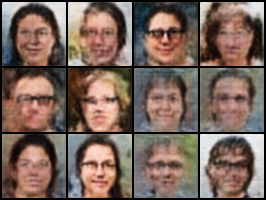
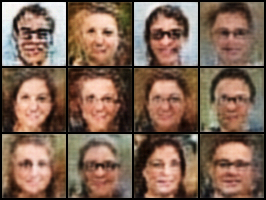
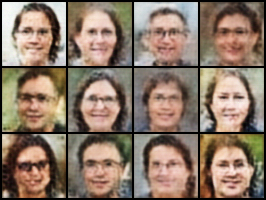
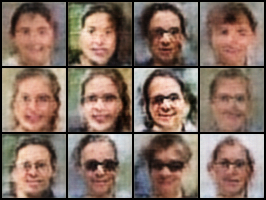
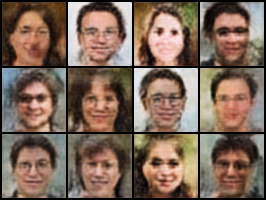
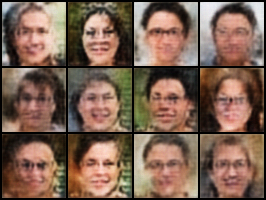
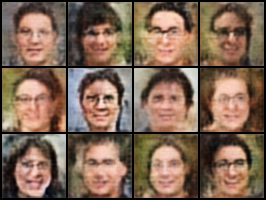
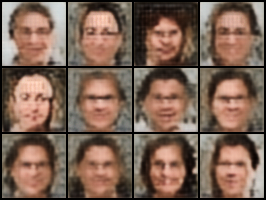
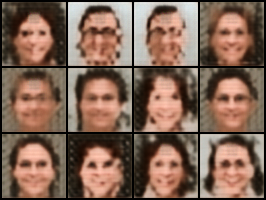
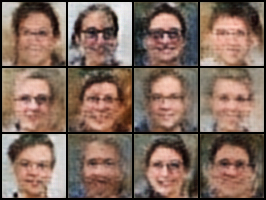
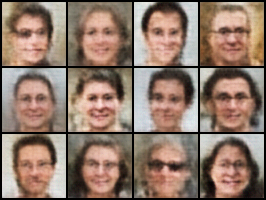

In [26]:
# Display results
if results:
    ablation_table = pd.DataFrame(results)
    ablation_table.to_csv(ablation_results_csv, index=False)
    ablation_table.to_json(ablation_results_json, orient="records", indent=2)
    print(f"\nSaved ablation results to {ablation_results_csv}")
    print(f"Saved ablation results to {ablation_results_json}")
    print("\n" + "="*50)
    print("ABLATION STUDY RESULTS")
    print("="*50)
    print(ablation_table[["experiment", "loss", "train_fid", "eval_fid", "train_is", "eval_is", "changed_params"]].to_string(index=False))
ablation_table = pd.DataFrame(results) if results else pd.DataFrame()
plot_ablation_cards(ablation_table)

Loaded ablation results from outputs/gan_ebm/ablation_results/ablation_results_run2.csv

ABLATION STUDY RESULTS


,experiment,loss,train_fid,eval_fid,train_is,eval_is,changed_params
0,base_2,-333.281921,137.823624,175.802841,1.497122,1.514561,NaN
1,k3_g1,-447.019257,133.937607,166.217575,1.543764,1.531362,"k_steps=3, g_steps=1"
2,k5_g2,-303.198166,136.052567,175.338104,1.551240,1.556157,"k_steps=5, g_steps=2"
3,g_relu_e_relu,-471.265816,140.487930,174.623215,1.537556,1.497289,"g_activation=relu, e_activation=relu"
4,g_gelu_e_leaky,-298.649509,136.400497,165.167725,1.517161,1.546821,"g_activation=gelu, e_activation=leakyrelu"
5,real70_fake30,-405.687431,149.333405,184.470886,1.659004,1.703398,real_ratio=0.7
6,real30_fake70,-320.414692,144.713272,179.981400,1.541330,1.591502,real_ratio=0.3
7,dropout_10,-250.969872,192.934265,218.974533,1.855857,1.728362,"g_dropout=0.1, e_dropout=0.1"
8,dropout_20,-276.080872,230.504166,270.380951,2.219184,2.208984,"g_dropout=0.2, e_dropout=0.2"
9,no_batchnorm_gen,-324.818228,156.404709,194.466309,1.512451,1.500746,use_batchnorm_gen=False


Experiment,base_2,k3_g1,k5_g2,g_relu_e_relu,g_gelu_e_leaky,real70_fake30,real30_fake70,dropout_10,dropout_20,no_batchnorm_gen,no_spectral_norm
Image,,,,,,,,,,,
Loss,-333.2819,-447.0193,-303.1982,-471.2658,-298.6495,-405.6874,-320.4147,-250.9699,-276.0809,-324.8182,-94.9458
Train FID,137.8236,133.9376,136.0526,140.4879,136.4005,149.3334,144.7133,192.9343,230.5042,156.4047,190.0419
Eval FID,175.8028,166.2176,175.3381,174.6232,165.1677,184.4709,179.9814,218.9745,270.3810,194.4663,232.1150
Train IS,1.4971,1.5438,1.5512,1.5376,1.5172,1.6590,1.5413,1.8559,2.2192,1.5125,1.5715
Eval IS,1.5146,1.5314,1.5562,1.4973,1.5468,1.7034,1.5915,1.7284,2.2090,1.5007,1.6185
Changes,nan,"k_steps=3, g_steps=1","k_steps=5, g_steps=2","g_activation=relu, e_activation=relu","g_activation=gelu, e_activation=leakyrelu",real_ratio=0.7,real_ratio=0.3,"g_dropout=0.1, e_dropout=0.1","g_dropout=0.2, e_dropout=0.2",use_batchnorm_gen=False,use_spectral_norm=False

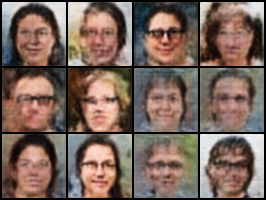
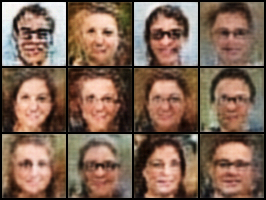
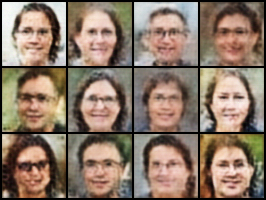
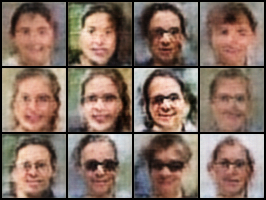
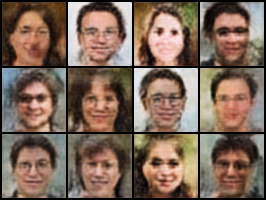
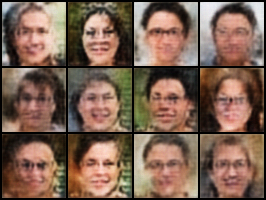
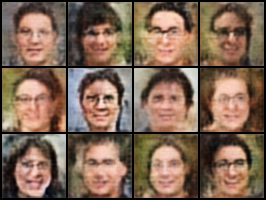
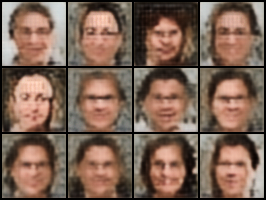
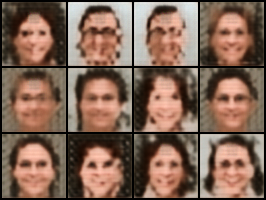
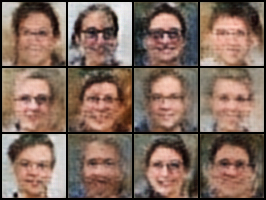
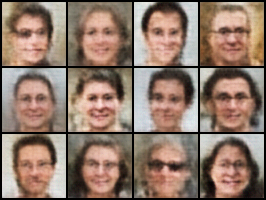

In [27]:
# Load saved ablation results for reformatting or reuse
ablation_result_run = 2  # Change to 2 to load the second saved ablation table
ablation_results_dir = os.path.join("outputs", "gan_ebm", "ablation_results")
ablation_results_csv = os.path.join(ablation_results_dir, f"ablation_results_run{ablation_result_run}.csv")
ablation_results_json = os.path.join(ablation_results_dir, f"ablation_results_run{ablation_result_run}.json")

if os.path.exists(ablation_results_csv):
    ablation_table = pd.read_csv(ablation_results_csv)
    print(f"Loaded ablation results from {ablation_results_csv}")
elif os.path.exists(ablation_results_json):
    ablation_table = pd.read_json(ablation_results_json)
    print(f"Loaded ablation results from {ablation_results_json}")
else:
    if "ablation_table" in globals() and not ablation_table.empty:
        print("Using in-memory ablation_table because no saved results file was found.")
    else:
        raise FileNotFoundError(
            f"No saved ablation results found for run {ablation_result_run}. Run the matching ablation cell first.",
        )

# Re-display table from saved results so formatting can be changed without rerunning experiments
if not ablation_table.empty:
    print("\n" + "="*50)
    print("ABLATION STUDY RESULTS")
    print("="*50)
    display(ablation_table[["experiment", "loss", "train_fid", "eval_fid", "train_is", "eval_is", "changed_params"]])
    plot_ablation_cards(ablation_table)

In [35]:
final_config = base_config.copy()
final_config["k_steps"] = 3
final_config["g_steps"] = 1
final_config["g_activation"] = "gelu"
final_config["e_activation"] = "leakyrelu"
final_config["use_batchnorm_gen"] = True  # Enable batch norm for generator
final_config["use_spectral_norm"] = True  # Enable spectral norm for discriminator

In [51]:
# Train final model with checkpoints, image generation, and metrics evaluation

EPOCHS = 300
CHECKPOINT_INTERVAL = 15  # Save every 20 epochs
EVAL_INTERVAL = 5  # Evaluate every 5 epochs

print(f"Training final model ({EPOCHS} epochs with checkpoints and evaluation)...")

checkpoint_dir = "models/gan_checkpoints"
image_checkpoint_dir = "outputs/gan_checkpoints"
metrics_dir = os.path.join("outputs", "gan_ebm", "final_metrics")
metrics_csv_path = os.path.join(metrics_dir, "final_metrics_history.csv")

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(image_checkpoint_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

metrics_history = {
    "epoch": [],
    "FID": [],
    "G_loss": [],
    "E_loss": [],
    "feature_matching_distance": [],
    "g_grad_norm": [],
    "e_grad_norm": [],
    "energy_real_mean": [],
    "energy_real_std": [],
    "energy_fake_mean": [],
    "energy_fake_std": [],
}

# Create generator and discriminator for final training
G_final, E_final = build_gan_models(final_config, device)
fixed_sample_noise = torch.randn(12, final_config["latent_dim"], 1, 1, device=device)

def collect_eval_metrics(generator, energy_net, dataloader, device, latent_dim, max_batches=4):
    """Collect feature matching and energy statistics on evaluation data."""
    was_generator_training = generator.training
    was_energy_training = energy_net.training
    generator.eval()
    energy_net.eval()

    feature_distance_sum = 0.0
    batch_count = 0
    real_energy_batches = []
    fake_energy_batches = []

    with torch.no_grad():
        for real_imgs, _ in dataloader:
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)
            z = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake_imgs = generator(z)

            real_features = energy_net.features_before_fc(real_imgs).flatten(1)
            fake_features = energy_net.features_before_fc(fake_imgs).flatten(1)
            feature_distance_sum += torch.norm(real_features.mean(dim=0) - fake_features.mean(dim=0), p=2).item()

            real_energy_batches.append(energy_net(real_imgs).detach().float().cpu())
            fake_energy_batches.append(energy_net(fake_imgs).detach().float().cpu())

            batch_count += 1
            if batch_count >= max_batches:
                break

    if was_generator_training:
        generator.train()
    if was_energy_training:
        energy_net.train()

    real_energy_tensor = torch.cat(real_energy_batches) if real_energy_batches else torch.tensor([])
    fake_energy_tensor = torch.cat(fake_energy_batches) if fake_energy_batches else torch.tensor([])

    return {
        "feature_matching_distance": feature_distance_sum / max(1, batch_count),
        "energy_real_mean": real_energy_tensor.mean().item() if real_energy_tensor.numel() else float("nan"),
        "energy_real_std": real_energy_tensor.std(unbiased=False).item() if real_energy_tensor.numel() else float("nan"),
        "energy_fake_mean": fake_energy_tensor.mean().item() if fake_energy_tensor.numel() else float("nan"),
        "energy_fake_std": fake_energy_tensor.std(unbiased=False).item() if fake_energy_tensor.numel() else float("nan"),
    }

def checkpoint_callback(epoch, generator, energy_net, g_loss, e_loss, g_grad_norm=None, e_grad_norm=None, opt_G_state_dict=None, opt_E_state_dict=None):
    """Called after each epoch to save checkpoints and evaluate."""
    epoch_num = epoch + 1

    # Save checkpoint every 20 epochs
    if epoch_num % CHECKPOINT_INTERVAL == 0:
        checkpoint_path = os.path.join(checkpoint_dir, f"gan_epoch_{epoch_num}.pth")

        payload = {
            "generator_state_dict": generator.state_dict(),
            "discriminator_state_dict": energy_net.state_dict(),
            "epoch": epoch_num,
            "config": final_config,
        }
        if opt_G_state_dict is not None:
            payload["optimizer_G_state_dict"] = opt_G_state_dict
        if opt_E_state_dict is not None:
            payload["optimizer_E_state_dict"] = opt_E_state_dict

        torch.save(payload, checkpoint_path)
        print(f"Checkpoint saved: epoch {epoch_num}")

        # Generate images from this checkpoint using the same latent batch every time.
        sample_path = os.path.join(image_checkpoint_dir, f"gan_epoch_{epoch_num}.png")
        save_samples(
            generator,
            device,
            sample_path,
            latent_dim=final_config["latent_dim"],
            fixed_noise=fixed_sample_noise,
        )
        print(f"Generated images saved: {sample_path}")

    # Evaluate every 5 epochs
    if epoch_num % EVAL_INTERVAL == 0:
        print(f"\nEvaluating at epoch {epoch_num}...")
        fid_score = compute_fid(
            generator,
            test_loader,
            device,
            latent_dim=final_config["latent_dim"],
        )
        eval_metrics = collect_eval_metrics(generator, energy_net, test_loader, device, final_config["latent_dim"])

        metrics_history["epoch"].append(epoch_num)
        metrics_history["FID"].append(fid_score)
        metrics_history["G_loss"].append(g_loss)
        metrics_history["E_loss"].append(e_loss)
        metrics_history["feature_matching_distance"].append(eval_metrics["feature_matching_distance"])
        metrics_history["g_grad_norm"].append(g_grad_norm if g_grad_norm is not None else float("nan"))
        metrics_history["e_grad_norm"].append(e_grad_norm if e_grad_norm is not None else float("nan"))
        metrics_history["energy_real_mean"].append(eval_metrics["energy_real_mean"])
        metrics_history["energy_real_std"].append(eval_metrics["energy_real_std"])
        metrics_history["energy_fake_mean"].append(eval_metrics["energy_fake_mean"])
        metrics_history["energy_fake_std"].append(eval_metrics["energy_fake_std"])

        print(
            f"Epoch {epoch_num} - FID: {fid_score:.2f}, FM: {eval_metrics['feature_matching_distance']:.4f}, "
            f"G grad: {g_grad_norm:.4f}, E grad: {e_grad_norm:.4f}"
        )

    # Clear VRAM for the next epoch/model step
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

G_losses_final, E_losses_final, opt_G_state_final, opt_E_state_final = train_gan_with_epoch_callback(
    generator=G_final,
    discriminator=E_final,
    dataloader=train_loader,
    device=device,
    epochs=EPOCHS,
    latent_dim=final_config["latent_dim"],
    lr=final_config["lr"],
    e_steps=final_config["k_steps"],
    g_steps=final_config["g_steps"],
    real_ratio=final_config["real_ratio"],
    gp_lambda=final_config["gp_lambda"],
    epoch_callback=checkpoint_callback,
    return_optimizer_states=True,
)

# Persist metrics so they can be loaded later for visualization without retraining.
metrics_df = pd.DataFrame(metrics_history)
metrics_df.to_csv(metrics_csv_path, index=False)
print(f"Saved metrics history to {metrics_csv_path}")

# Save final checkpoints with discriminator + optimizer states so training can be resumed exactly.
final_ckpt_model_path = os.path.join(checkpoint_dir, "gan_final.pth")
final_resume_ckpt_path = os.path.join(checkpoint_dir, "gan_final_resume.pth")
final_ckpt_output_g_path = "outputs/final_generator.pth"
final_ckpt_output_d_path = "outputs/final_discriminator.pth"

final_payload = {
    "generator_state_dict": G_final.state_dict(),
    "discriminator_state_dict": E_final.state_dict(),
    "energy_net_state_dict": E_final.state_dict(),  # alias for EBM naming compatibility
    "optimizer_G_state_dict": opt_G_state_final,
    "optimizer_E_state_dict": opt_E_state_final,
    "epoch": EPOCHS,
    "config": final_config,
}

# Resume payload stores extra training history metadata for convenience.
final_resume_payload = {
    **final_payload,
    "G_losses": G_losses_final,
    "E_losses": E_losses_final,
    "metrics_history": metrics_history,
}

torch.save(final_payload, final_ckpt_model_path)
torch.save(final_resume_payload, final_resume_ckpt_path)
torch.save({"generator_state_dict": G_final.state_dict(), "config": final_config}, final_ckpt_output_g_path)
torch.save({"discriminator_state_dict": E_final.state_dict(), "config": final_config}, final_ckpt_output_d_path)

print(f"✓ Final checkpoint saved to {final_ckpt_model_path}")
print(f"✓ Final resume checkpoint saved to {final_resume_ckpt_path}")
print(f"✓ Final generator checkpoint saved to {final_ckpt_output_g_path}")
print(f"✓ Final discriminator checkpoint saved to {final_ckpt_output_d_path}")
print("\n✓ Training completed!")

Training final model (300 epochs with checkpoints and evaluation)...


Epoch [5/300]: 100%|██████████| 141/141 [00:19<00:00,  7.12it/s, E_loss=2036.5398, G_loss=-571.6115]



Evaluating at epoch 5...
Epoch 5 - FID: 477.80, FM: 36.8177, G grad: 553.5321, E grad: 14027.0420


Epoch [10/300]: 100%|██████████| 141/141 [00:19<00:00,  7.13it/s, E_loss=2012.7216, G_loss=-1096.3087]



Evaluating at epoch 10...
Epoch 10 - FID: 382.76, FM: 117.9538, G grad: 367.7944, E grad: 8890.7160


...


Evaluating at epoch 290...
Epoch 290 - FID: 122.21, FM: 8.1378, G grad: 52.9926, E grad: 107.1144


Epoch [295/300]: 100%|██████████| 141/141 [00:19<00:00,  7.11it/s, E_loss=-2.4572, G_loss=-678.4546]



Evaluating at epoch 295...
Epoch 295 - FID: 120.22, FM: 7.1307, G grad: 54.7213, E grad: 99.1971


Epoch [300/300]: 100%|██████████| 141/141 [00:19<00:00,  7.12it/s, E_loss=3.9524, G_loss=-698.4518] 


Checkpoint saved: epoch 300
Generated images saved: outputs/gan_checkpoints/gan_epoch_300.png

Evaluating at epoch 300...
Epoch 300 - FID: 124.70, FM: 4.9859, G grad: 54.0720, E grad: 98.0378
Saved metrics history to outputs/gan_ebm/final_metrics/final_metrics_history.csv
✓ Final checkpoint saved to models/gan_checkpoints/gan_final.pth
✓ Final resume checkpoint saved to models/gan_checkpoints/gan_final_resume.pth
✓ Final generator checkpoint saved to outputs/final_generator.pth
✓ Final discriminator checkpoint saved to outputs/final_discriminator.pth

✓ Training completed!


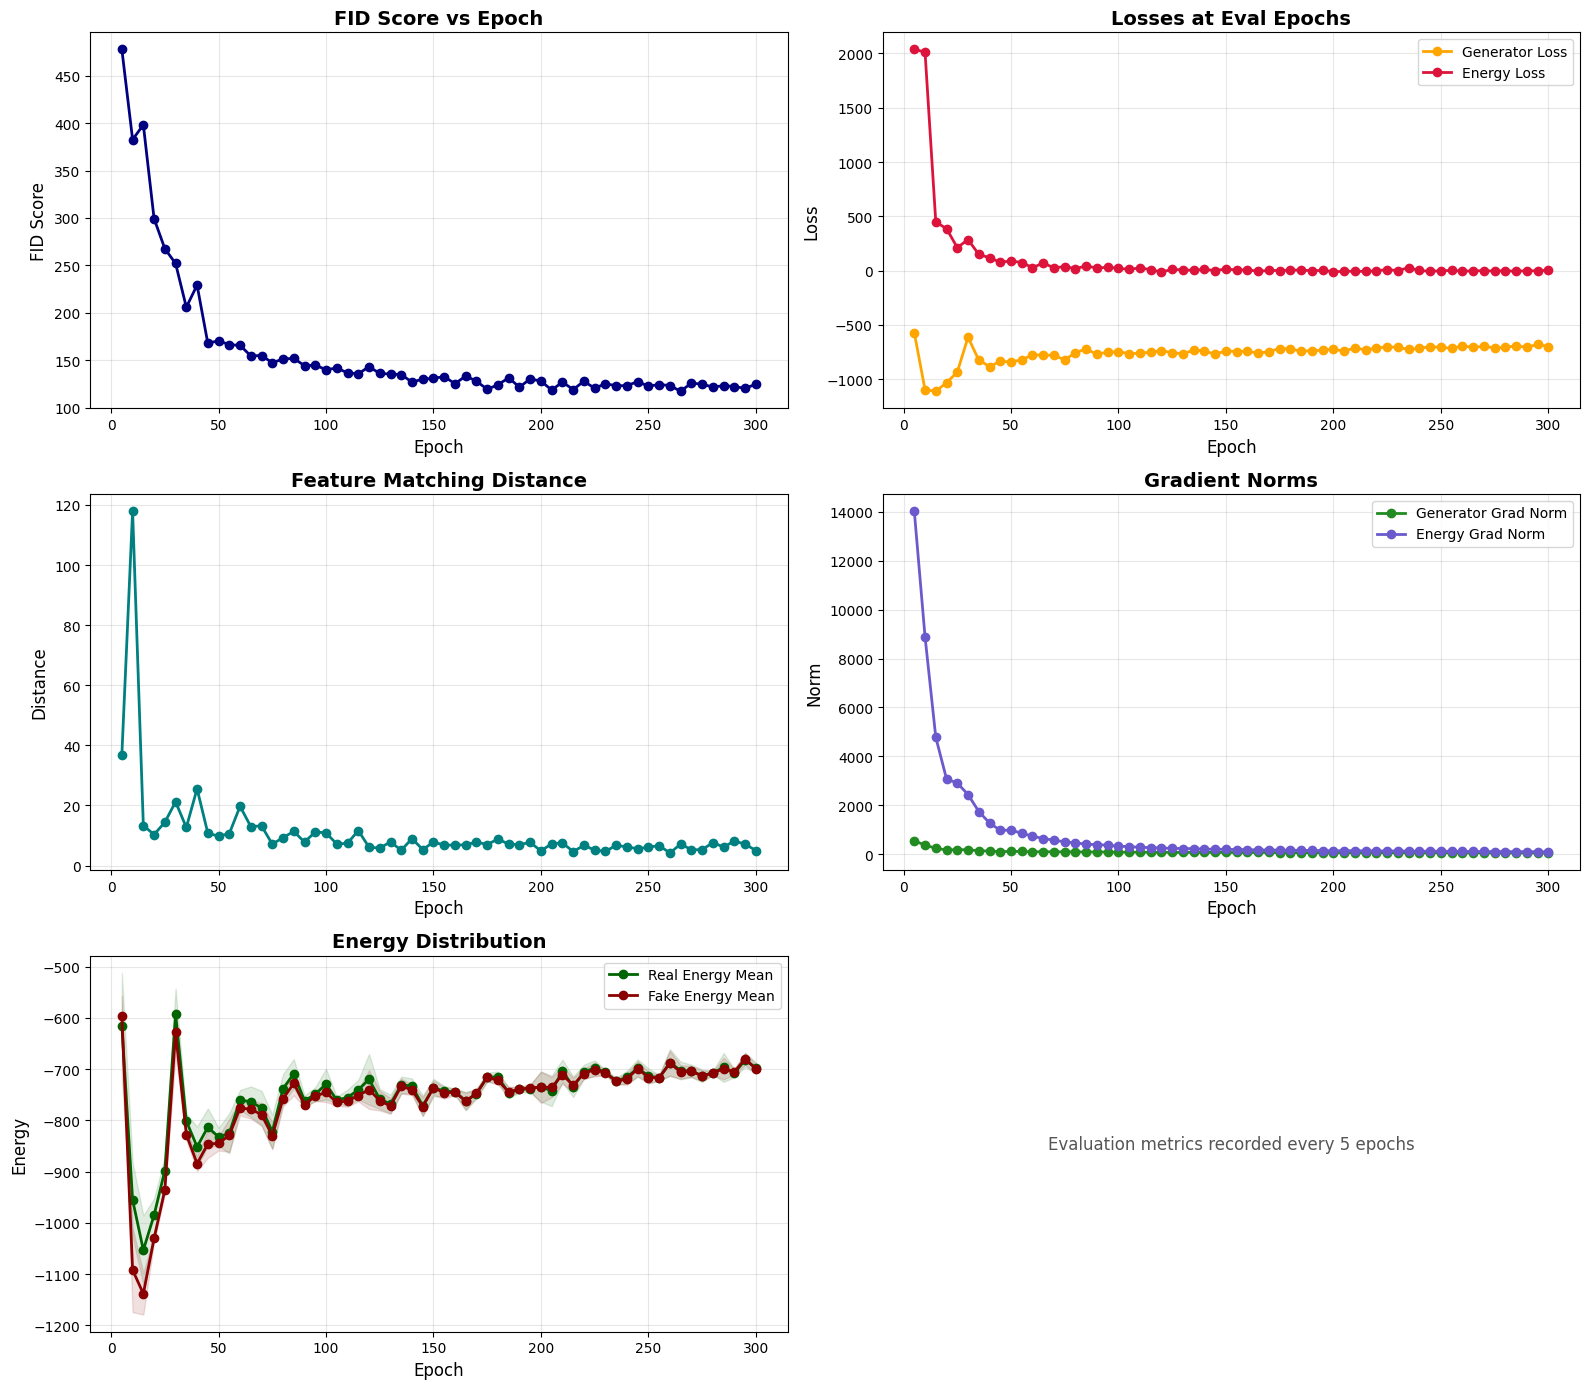


METRICS SUMMARY
 epoch        FID       G_loss      E_loss  feature_matching_distance  g_grad_norm  e_grad_norm  energy_real_mean  energy_real_std  energy_fake_mean  energy_fake_std
     5 477.801697  -571.611511 2036.539795                  36.817695   553.532146 14027.042011       -615.123657       103.385918       -596.998535        39.874401
    10 382.757812 -1096.308716 2012.721558                 117.953754   367.794385  8890.716034       -954.845459        72.857765      -1091.716553        82.226921
    15 398.215393 -1110.764038  447.919067                  13.274952   248.163181  4781.414720      -1052.805908        67.466888      -1138.020264        40.790794
    20 299.215698 -1031.492798  386.477234                  10.308705   173.241643  3075.002506       -984.570801        32.367008      -1030.226074         7.116053
    25 267.622162  -933.952637  212.055817                  14.396023   188.591131  2909.517148       -897.730225        27.148392       -935.569519     

In [52]:
# Visualize metrics against epochs
metrics_csv_path = os.path.join("outputs", "gan_ebm", "final_metrics", "final_metrics_history.csv")

# Load saved metrics if current session does not already have them.
if (
    "metrics_history" not in globals()
    or "epoch" not in metrics_history
    or len(metrics_history["epoch"]) == 0
):
    if os.path.exists(metrics_csv_path):
        loaded_metrics_df = pd.read_csv(metrics_csv_path)
        metrics_history = {column: loaded_metrics_df[column].tolist() for column in loaded_metrics_df.columns}
        print(f"Loaded metrics history from {metrics_csv_path}")
    else:
        print(f"No metrics found at {metrics_csv_path}. Run the final training cell first.")

if "metrics_history" in globals() and metrics_history.get("epoch"):
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))

    # FID Score Plot
    axes[0, 0].plot(metrics_history["epoch"], metrics_history["FID"], marker='o', linewidth=2, markersize=6, color='navy')
    axes[0, 0].set_xlabel("Epoch", fontsize=12)
    axes[0, 0].set_ylabel("FID Score", fontsize=12)
    axes[0, 0].set_title("FID Score vs Epoch", fontsize=14, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)

    # Losses at evaluation epochs
    axes[0, 1].plot(metrics_history["epoch"], metrics_history["G_loss"], marker='o', color='orange', linewidth=2, markersize=6, label='Generator Loss')
    axes[0, 1].plot(metrics_history["epoch"], metrics_history["E_loss"], marker='o', color='crimson', linewidth=2, markersize=6, label='Energy Loss')
    axes[0, 1].set_xlabel("Epoch", fontsize=12)
    axes[0, 1].set_ylabel("Loss", fontsize=12)
    axes[0, 1].set_title("Losses at Eval Epochs", fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Feature matching distance
    axes[1, 0].plot(metrics_history["epoch"], metrics_history["feature_matching_distance"], marker='o', linewidth=2, markersize=6, color='teal')
    axes[1, 0].set_xlabel("Epoch", fontsize=12)
    axes[1, 0].set_ylabel("Distance", fontsize=12)
    axes[1, 0].set_title("Feature Matching Distance", fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)

    # Gradient norms
    axes[1, 1].plot(metrics_history["epoch"], metrics_history["g_grad_norm"], marker='o', linewidth=2, markersize=6, color='forestgreen', label='Generator Grad Norm')
    axes[1, 1].plot(metrics_history["epoch"], metrics_history["e_grad_norm"], marker='o', linewidth=2, markersize=6, color='slateblue', label='Energy Grad Norm')
    axes[1, 1].set_xlabel("Epoch", fontsize=12)
    axes[1, 1].set_ylabel("Norm", fontsize=12)
    axes[1, 1].set_title("Gradient Norms", fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    # Energy distribution summary
    axes[2, 0].plot(metrics_history["epoch"], metrics_history["energy_real_mean"], marker='o', linewidth=2, markersize=6, color='darkgreen', label='Real Energy Mean')
    axes[2, 0].plot(metrics_history["epoch"], metrics_history["energy_fake_mean"], marker='o', linewidth=2, markersize=6, color='darkred', label='Fake Energy Mean')
    real_lower = [m - s for m, s in zip(metrics_history["energy_real_mean"], metrics_history["energy_real_std"])]
    real_upper = [m + s for m, s in zip(metrics_history["energy_real_mean"], metrics_history["energy_real_std"])]
    fake_lower = [m - s for m, s in zip(metrics_history["energy_fake_mean"], metrics_history["energy_fake_std"])]
    fake_upper = [m + s for m, s in zip(metrics_history["energy_fake_mean"], metrics_history["energy_fake_std"])]
    axes[2, 0].fill_between(metrics_history["epoch"], real_lower, real_upper, color='darkgreen', alpha=0.12)
    axes[2, 0].fill_between(metrics_history["epoch"], fake_lower, fake_upper, color='darkred', alpha=0.12)
    axes[2, 0].set_xlabel("Epoch", fontsize=12)
    axes[2, 0].set_ylabel("Energy", fontsize=12)
    axes[2, 0].set_title("Energy Distribution", fontsize=14, fontweight='bold')
    axes[2, 0].grid(True, alpha=0.3)
    axes[2, 0].legend()

    # Hide unused panel while keeping a uniform layout
    axes[2, 1].axis("off")
    axes[2, 1].text(0.5, 0.5, "Evaluation metrics recorded every 5 epochs", ha="center", va="center", fontsize=12, color="#555")

    plt.tight_layout()
    plt.savefig("outputs/gan_metrics_visualization.png", dpi=150, bbox_inches='tight')
    plt.show()

    # Print metrics summary
    print("\n" + "=" * 60)
    print("METRICS SUMMARY")
    print("=" * 60)
    metrics_df = pd.DataFrame(metrics_history)
    print(metrics_df.to_string(index=False))
    print("=" * 60)
else:
    print("No metrics recorded. Ensure evaluation was run or the metrics CSV exists.")

Generating samples from loaded model...


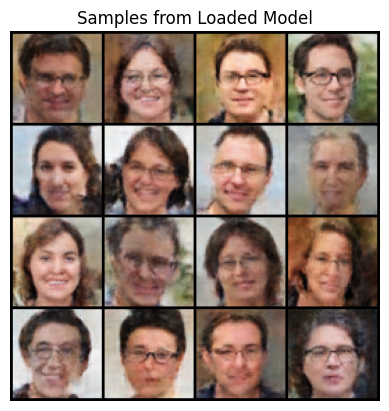

Loaded Model - FID: 123.11, IS: 1.62


In [55]:
# Load final checkpoint and sample from it
checkpoint_path = os.path.join("models", "gan_checkpoints", "gan_final.pth")
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

G_loaded = None
samples = None
checkpoint = None
config_loaded = None

try:
    checkpoint = torch.load(checkpoint_path, map_location=device)
    config_loaded = checkpoint.get("config", final_config)

    # Build model from config, then load weights
    G_loaded, _ = build_gan_models(config_loaded, device)
    G_loaded.load_state_dict(checkpoint["generator_state_dict"])
    G_loaded.eval()

    # Random sampling (new noise each run)
    print("Generating samples from loaded model...")
    samples = generate_samples(
        G_loaded,
        device,
        config_loaded["latent_dim"],
        n_samples=16,
    )
    show_images(samples, "Samples from Loaded Model")

    # Save a random sample image
    save_samples(
        G_loaded,
        device,
        "outputs/loaded_model_samples.png",
        latent_dim=config_loaded["latent_dim"],
    )

    # Evaluate loaded model
    fid_loaded = compute_fid(
        G_loaded,
        test_loader,
        device,
        latent_dim=config_loaded["latent_dim"],
    )
    is_loaded = compute_is(
        G_loaded,
        device,
        latent_dim=config_loaded["latent_dim"],
    )
    print(f"Loaded Model - FID: {fid_loaded:.2f}, IS: {is_loaded:.2f}")

finally:
    free_model_memory(G_loaded)
    for var_name in ("G_loaded", "checkpoint", "samples", "config_loaded"):
        globals().pop(var_name, None)